# ***Notebook for data preparation for YOLO model training***
- Bounding Box for box detection (object localization)
- Oriented Bounding Box for oriented object detection and loccalization
- Instance Masks for instance segmentation

Note: The dataset is Very High Resolution drone imagery obtained from [Open Aerial Maps](https://map.openaerialmap.org/#/33.47534179687499,0.26367094433665017,6?_k=xixa3o)

In [ ]:
!uv pip install -U imagecodecs
!uv pip install leafmap
!uv pip install localtileserver
!uv pip install kagglehub
!pip install --upgrade numpy
!pip install --upgrade scikit-image

Using Python 3.12.13 environment at: /usr
Resolved 2 packages in 30ms
Checked 2 packages in 0.30ms
Using Python 3.12.13 environment at: /usr
Checked 1 package in 90ms
Using Python 3.12.13 environment at: /usr
Checked 1 package in 95ms
Using Python 3.12.13 environment at: /usr
Checked 1 package in 112ms


In [ ]:
import kagglehub
import os
from google.colab import drive
import sys

# Connect Google drive for saving and accessing files

In [ ]:
drive.mount('/content/drive')
root_folder = "/content/drive/MyDrive/Deep-Learning-Building-Extraction-master"

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## **Connect the local scrit folder to use cutom functions**

In [ ]:
import sys
sys.path.append(f"{root_folder}/scripts")


### **Load custom preprocessing scripts**
The folowing cell imports scripts from the local folder. The scripts are usefull for tiling the input image

In [ ]:
import prepare_yolo_mask as masker
from train_plotter import plot_yolo_bbox_dataset, plot_yolo_segmentation_dataset, plot_yolo_obb_dataset
from tiling_and_visualization import tile_raster, plot_binary_mask, tile_visualize

## **Access data from remote server**

We will access the data stored in Kaggle using its own access API as follows

In [ ]:
data_path = kagglehub.dataset_download("getachewworkineh/kakuma-ceos-training")
print("Path to dataset files:", data_path)
print("Datasets in the folder: ", os.listdir(data_path))

Using Colab cache for faster access to the 'kakuma-ceos-training' dataset.
Path to dataset files: /kaggle/input/kakuma-ceos-training
Datasets in the folder:  ['kutupalong_f.tif', 'kutupalong_a.tif', 'valid.tif', 'training.geojson', 'train.tif', 'test.tif', 'validation.geojson']


### ***Proper tile selection through visualization***

In [ ]:
train_file = 'train.tif'
raster_file = os.path.join(data_path, train_file)
tile_height = 640
tile_width = 640
stride_y = 630
stride_x = 630
tile_visualize(raster_file=raster_file,
                   tile_height=tile_height,
                   tile_width=tile_width,
                   stride_y=stride_y,
                   stride_x=stride_x,
                   with_tiles=True)

100%|██████████| 25/25 [00:00<00:00, 397.47it/s]


Map(center=[3.750916, 34.804950500000004], controls=(ZoomControl(options=['position', 'zoom_in_text', 'zoom_in…

### **Specify the input shapefile or mask and raster image and perform image tiling or create sample chips**
 - **tile training data**

In [ ]:
input_raster = os.path.join(data_path, 'train.tif')
input_mask_file = os.path.join(data_path, 'training.geojson')
output_train_directory = f"{root_folder}/raw_dataset/train"


tile_size = 640
stride = 640
background_value = 0

tile_raster(
        input_raster=input_raster,
        output_dir=output_train_directory,
        input_mask_file=input_mask_file,
        tile_size=tile_size,
        stride=stride,
        background_value=background_value)

Raster dimensions: 15423 x 13379
Number of tiles including background: 24 x 20

Successfully created 371 chips


## Visualize tiled training images and corresponding masks

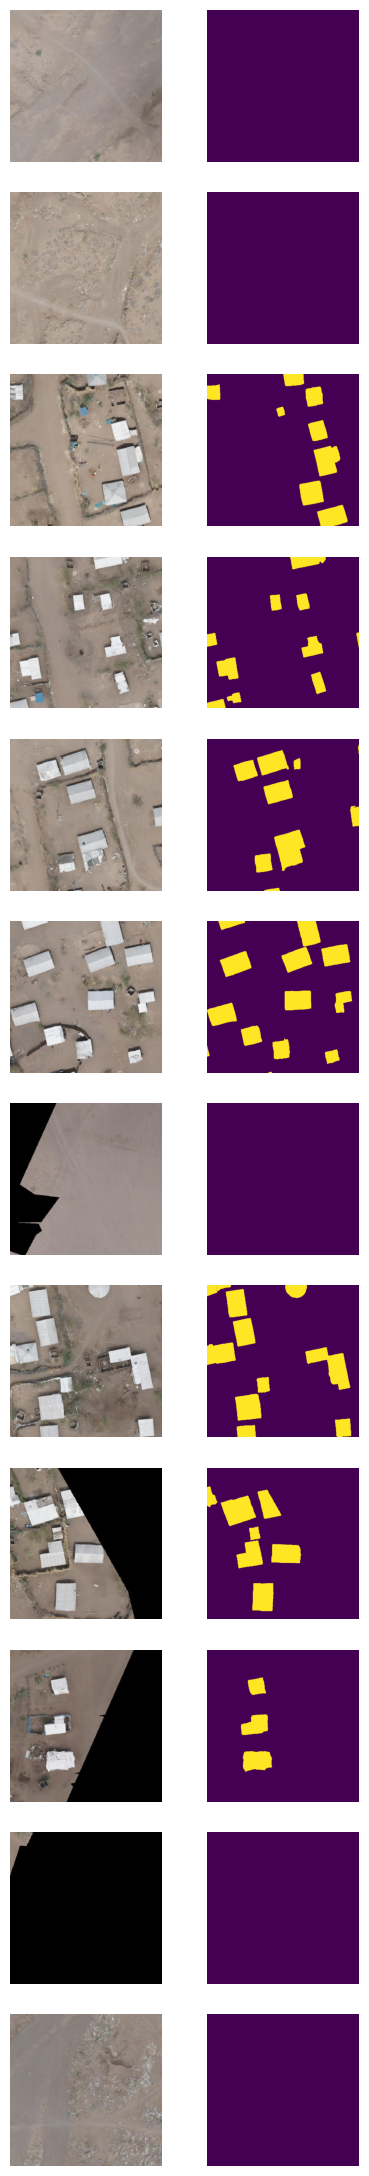

In [ ]:
plot_binary_mask(file_path=output_train_directory, n_samples=12)

  - **tile validation data**

In [ ]:
input_raster = os.path.join(data_path, 'valid.tif')
input_mask_file = os.path.join(data_path, 'validation.geojson')
output_valid_directory = f"{root_folder}/raw_dataset/valid"


tile_size = 640
stride = 640
background_value = 0

tile_raster(
        input_raster=input_raster,
        output_dir=output_valid_directory,
        input_mask_file=input_mask_file,
        tile_size=tile_size,
        stride=stride,
        background_value=background_value)

Raster dimensions: 14511 x 15460
Number of tiles including background: 22 x 24

Successfully created 324 chips


## Visualize tiled validation images and corresponding masks

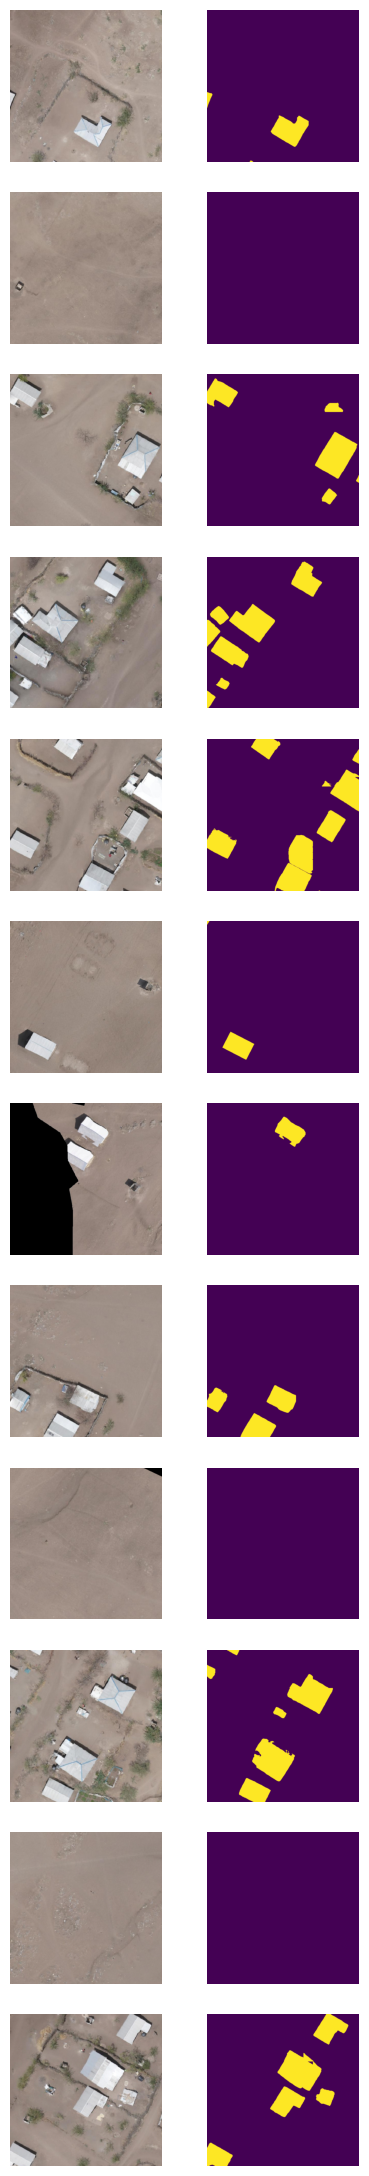

In [ ]:
plot_binary_mask(file_path=output_valid_directory, n_samples=12)

 - **Tile test data**

In [ ]:
input_raster = os.path.join(data_path, 'test.tif')
output_test_directory = f"{root_folder}/raw_dataset/test"


tile_size = 640
stride = 640
background_value = 0

tile_raster(
        input_raster=input_raster,
        output_dir=output_test_directory,
        input_mask_file=None,
        tile_size=tile_size,
        stride=stride,
        background_value=background_value)

Raster dimensions: 24145 x 46190
Number of tiles including background: 37 x 72

Successfully created 1333 chips


### **Specify the path that contains the tiles path and convert classified tiles into YOLO sample format**

- Specify the input directory where the tiled chips are saved
Specify the output directory where samples prepared as YOLO format will be saved

In [ ]:
input_path_train = output_train_directory
input_path_valid = output_valid_directory


output_path_bbox = f"{root_folder}/yolo_dataset/bbox"        # for bounding box detection
output_path_obbox = f"{root_folder}/yolo_dataset/obbox"      # for oriented bounding box detection
output_path_segment = f"{root_folder}/yolo_dataset/segment"  # for instance segmentation

### ***Bounding Box Format***

In [ ]:
# train
masker.prepare_yolo_data(data_dir=input_path_train,
                          out_dir=output_path_bbox,
                          ext='tif',
                          part="train",
                          output="bbox", # annotation format
                          upsample=False,
                          tobits=False,
                         write_config=True)
# Valid
masker.prepare_yolo_data(data_dir=input_path_valid,
                          out_dir=output_path_bbox,
                          ext='tif',
                          part="valid",
                          output="bbox",
                          upsample=False,
                          tobits=False,
                         write_config=False)

Started the training sample saving, with a total of 371


1it [00:01,  1.13s/it]

Mask main 0 and max 1 


371it [02:05,  2.94it/s]


Started the training sample saving, with a total of 324


1it [00:00,  1.51it/s]

Mask main 0 and max 0 


324it [01:43,  3.13it/s]


### ***Oriented bounding box***

In [ ]:
# train
masker.prepare_yolo_data(data_dir=input_path_train,
                          out_dir=output_path_obbox,
                          ext='tif',
                          part="train",
                          output="obbox",
                          upsample=False,
                          tobits=False,
                         write_config=True)
# valid
masker.prepare_yolo_data(data_dir=input_path_valid,
                          out_dir=output_path_obbox,
                          ext='tif',
                          part="valid",
                          output="obbox",
                          upsample=False,
                          tobits=False,
                         write_config=False)

Started the training sample saving, with a total of 371


1it [00:00,  9.43it/s]

Mask main 0 and max 1 


371it [00:27, 13.54it/s]


Started the training sample saving, with a total of 324


2it [00:00, 17.92it/s]

Mask main 0 and max 0 


324it [00:23, 13.67it/s]


### ***Instance segmentation masks***

In [ ]:
# Train
masker.prepare_yolo_data(data_dir=input_path_train,
                          out_dir=output_path_segment,
                          ext='tif',
                          part="train",
                          output="segment",
                          upsample=False,
                          tobits=False,
                         write_config=True)
# Valid

masker.prepare_yolo_data(data_dir=input_path_valid,
                          out_dir=output_path_segment,
                          ext='tif',
                          part="valid",
                          output="segment",
                          upsample=False,
                          tobits=False,
                         write_config=False)

Started the training sample saving, with a total of 371


2it [00:00, 15.40it/s]

Mask main 0 and max 1 


371it [00:32, 11.31it/s]


Started the training sample saving, with a total of 324


0it [00:00, ?it/s]

Mask main 0 and max 0 


324it [00:32,  9.92it/s]


### ***Visualize samples converted into YOLO Bounding Box format***

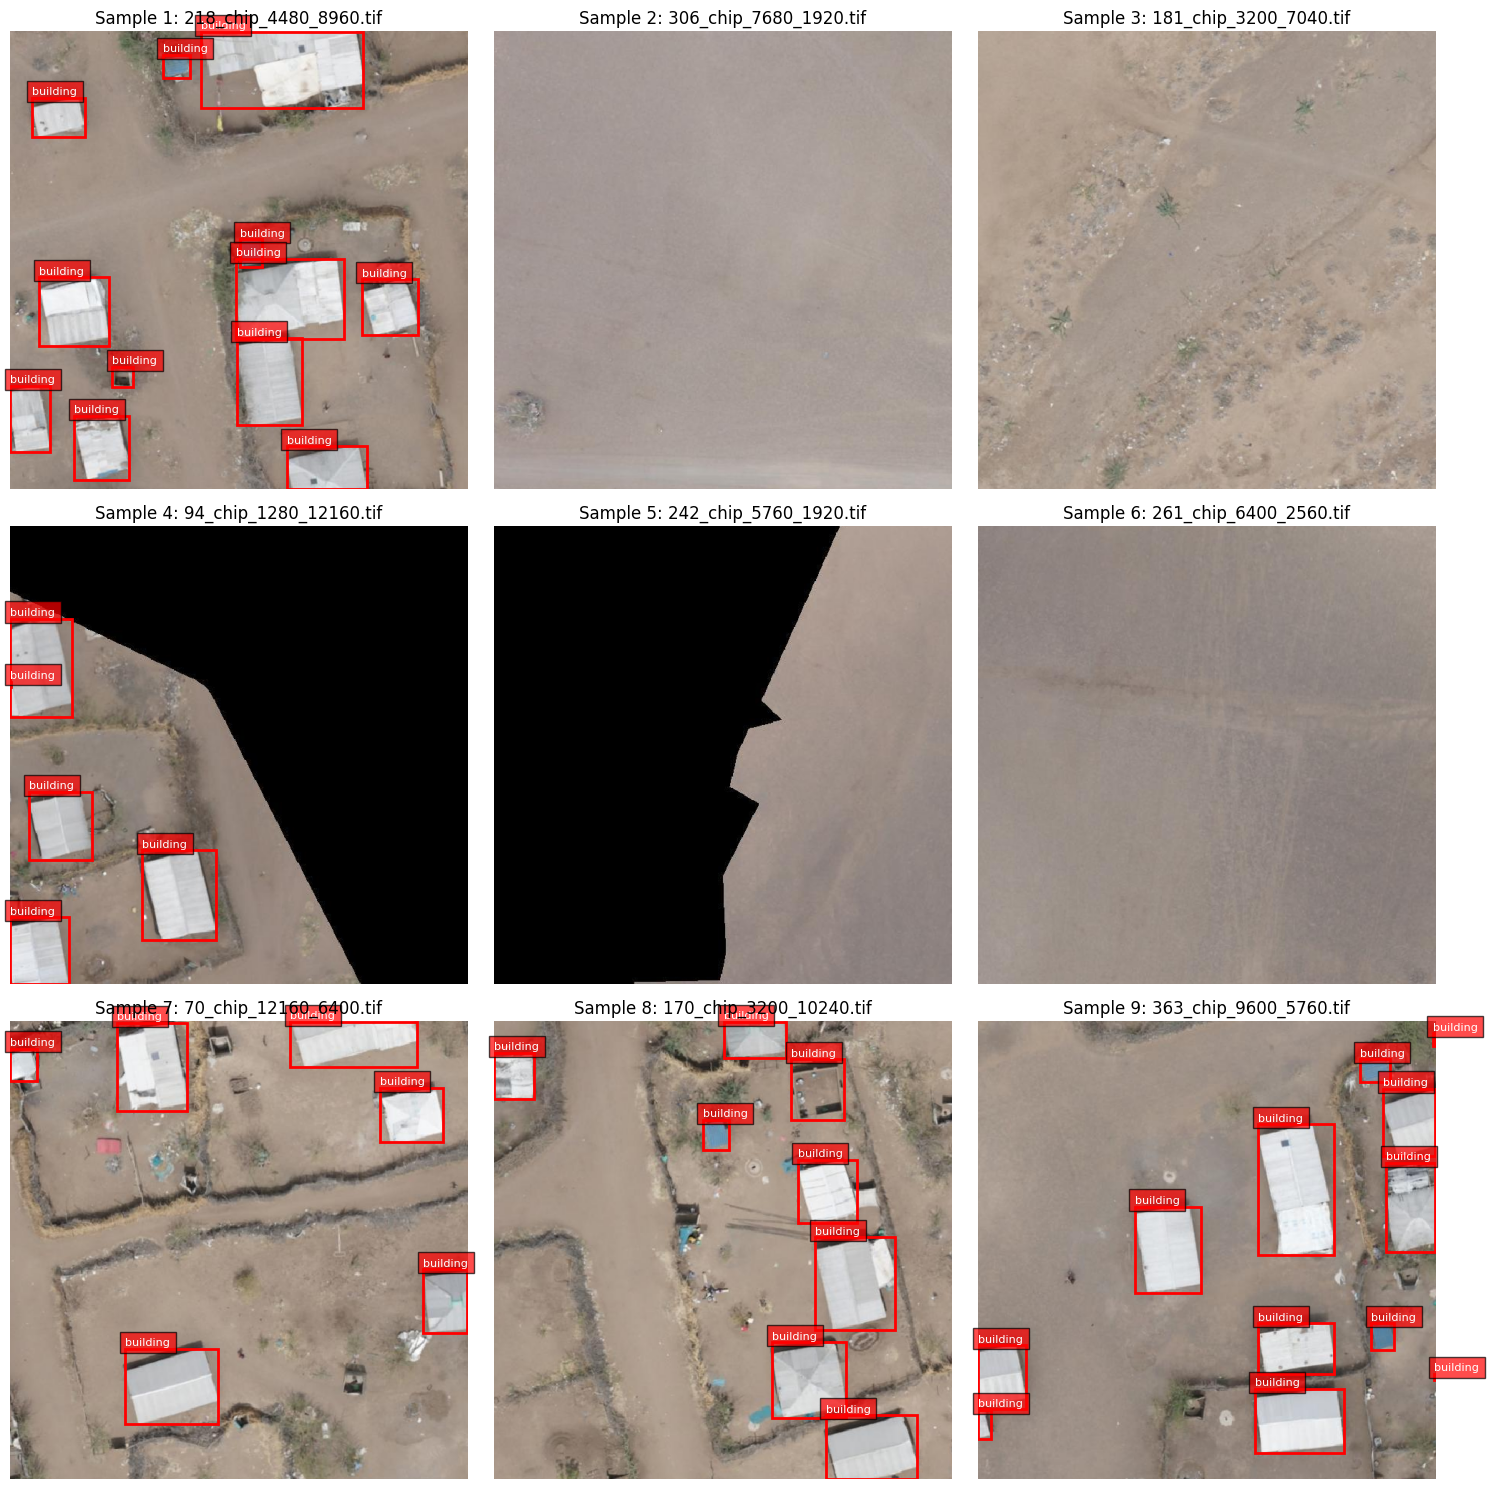

In [ ]:
class_names = ['building']
dataset_path = output_path_bbox + "/dataset/train"
plot_yolo_bbox_dataset(
    dataset_path=dataset_path,
    num_samples=9,
    class_names=class_names,
    ext="*.tif"
)

### ***Visualize samples converted into YOLO Oriented Bounding Box format***

/content/drive/MyDrive/Deep-Learning-Building-Extraction-master/yolo_dataset/obbox/dataset/train/labels/100_chip_1280_7040.txt
/content/drive/MyDrive/Deep-Learning-Building-Extraction-master/yolo_dataset/obbox/dataset/train/labels/171_chip_3200_10880.txt
/content/drive/MyDrive/Deep-Learning-Building-Extraction-master/yolo_dataset/obbox/dataset/train/labels/230_chip_5120_5120.txt
/content/drive/MyDrive/Deep-Learning-Building-Extraction-master/yolo_dataset/obbox/dataset/train/labels/295_chip_7040_5760.txt
/content/drive/MyDrive/Deep-Learning-Building-Extraction-master/yolo_dataset/obbox/dataset/train/labels/349_chip_8960_7680.txt
/content/drive/MyDrive/Deep-Learning-Building-Extraction-master/yolo_dataset/obbox/dataset/train/labels/317_chip_7680_8960.txt
/content/drive/MyDrive/Deep-Learning-Building-Extraction-master/yolo_dataset/obbox/dataset/train/labels/321_chip_8320_1280.txt
/content/drive/MyDrive/Deep-Learning-Building-Extraction-master/yolo_dataset/obbox/dataset/train/labels/254_ch

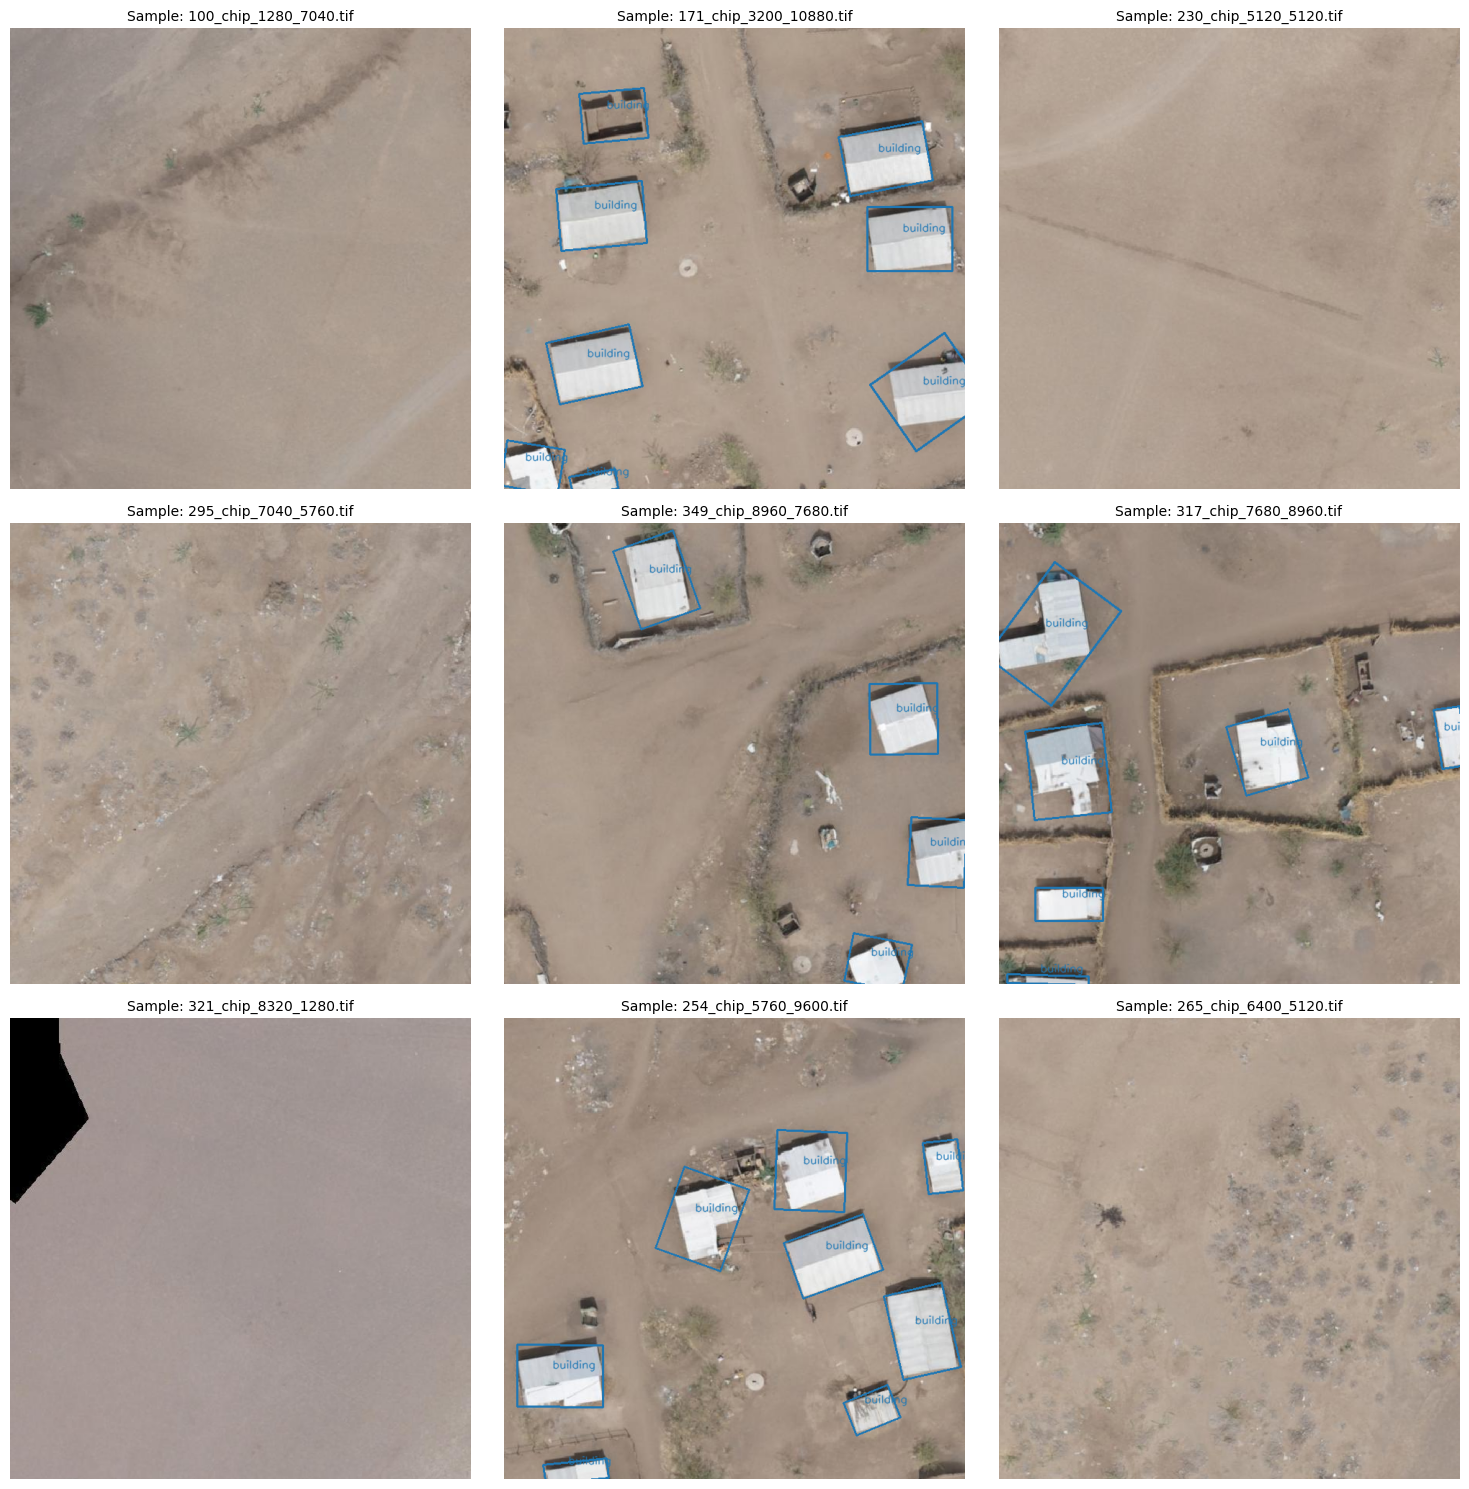

In [ ]:
dataset_path = output_path_obbox + "/dataset/train"
class_nmes = ["building"]

plot_yolo_obb_dataset(
        dataset_path=dataset_path,
        class_names=class_nmes,
        num_samples=9,
        ext="*.tif"
    )

### ***Visualize samples converted into YOLO instance segmentation format***

In [ ]:
dataset_path = output_path_segment + "/dataset/valid"
class_names = ["building"]
print("Plotting dataset samples...")
plot_yolo_segmentation_dataset(dataset_path=dataset_path,
                               num_samples=9,
                               class_names=class_names,
                               ext="*.tif")

Output hidden; open in https://colab.research.google.com to view.